# Self-exciting Hawkes Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/hawkes_from_scratch_and_numpyro.ipynb)

A **Hawkes process** has a self-exciting conditional intensity: past events temporarily raise the rate of future events. With an exponential kernel,

$$\lambda^*(t) = \mu + \alpha \sum_{t_i < t} e^{-\beta (t - t_i)}.$$

The process is **sub-critical** (stationary) when $\alpha / \beta < 1$. The compensator on $[0, T]$ has the closed form

$$\Lambda(T) = \mu T + \frac{\alpha}{\beta} \sum_i \big(1 - e^{-\beta (T - t_i)}\big).$$

This notebook walks through the two APIs:

1. **From scratch** — use the primitives `exp_hawkes_sample`, `exp_hawkes_intensity`, `exp_hawkes_log_prob` to simulate and sanity-check.
2. **With NumPyro** — wrap the process in the `ExponentialHawkes` distribution and run NUTS to recover $(\mu, \alpha, \beta)$ from synthetic data.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes.distributions import ExponentialHawkes as HawkesDist
from xtremax.point_processes.operators import ExponentialHawkes
from xtremax.point_processes.primitives import (
    exp_hawkes_intensity,
    exp_hawkes_sample,
)


key = random.PRNGKey(0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From Scratch: Primitives

Simulate an aftershock-style cluster with $\mu = 0.5$, $\alpha = 0.6$, $\beta = 1.2$ ($\alpha/\beta = 0.5$, comfortably sub-critical).

In [2]:
mu, alpha, beta, T = 0.5, 0.6, 1.2, 30.0
times, mask, _ = exp_hawkes_sample(key, T, mu, alpha, beta, max_events=512)
event_times = jnp.sort(jnp.where(mask, times, T))
print(f"n events = {int(jnp.sum(mask))}, expected ~ {mu * T / (1 - alpha / beta):.1f}")

n events = 32, expected ~ 30.0


Plot the intensity path alongside the events — the characteristic Hawkes "jumps-then-decay" is clearly visible.

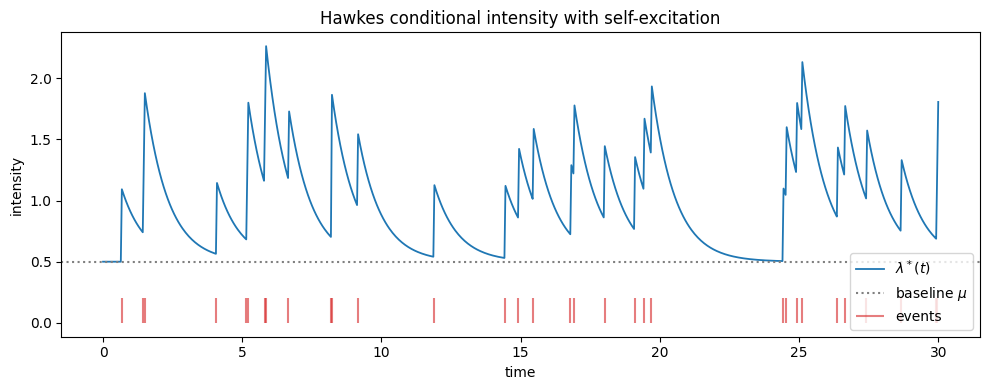

In [3]:
t_grid = jnp.linspace(0.0, T, 800)
intensity_path = jax.vmap(
    lambda t: exp_hawkes_intensity(t, times, mask, mu, alpha, beta)
)(t_grid)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_grid, intensity_path, color="C0", lw=1.3, label=r"$\lambda^*(t)$")
ax.axhline(mu, color="grey", linestyle=":", label=r"baseline $\mu$")
ev = np.asarray(times[mask])
ax.vlines(ev, 0, 0.2, color="C3", label="events", alpha=0.6)
ax.set_xlabel("time")
ax.set_ylabel("intensity")
ax.legend()
ax.set_title("Hawkes conditional intensity with self-excitation")
plt.tight_layout()
plt.show()

### Diagnostic: time-rescaling residuals

Under the time-rescaling theorem $\tau_i = \Lambda(t_i) - \Lambda(t_{i-1})$ is iid $\mathrm{Exp}(1)$ when the compensator is correct. Using the wrong compensator (e.g. assuming HPP) breaks the fit obviously.

KS statistic vs Exp(1) = 0.095
KS statistic under wrong (HPP) compensator = 0.101


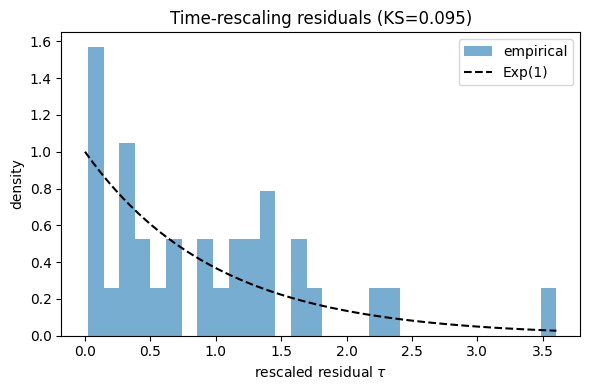

In [4]:
op = ExponentialHawkes(mu=mu, alpha=alpha, beta=beta, observation_window=T)
gof = op.goodness_of_fit(times, mask)
print(f"KS statistic vs Exp(1) = {float(gof.ks_statistic):.3f}")

# HPP residuals on the same events — wildly worse.
wrong_cum = lambda t: (int(jnp.sum(mask)) / T) * t
from xtremax.point_processes.primitives.diagnostics import (
    ks_statistic_exp1,
    time_rescaling_residuals,
)


res_wrong, m_wrong = time_rescaling_residuals(times, mask, wrong_cum)
print(
    f"KS statistic under wrong (HPP) compensator = {float(ks_statistic_exp1(res_wrong, m_wrong)):.3f}"
)

fig, ax = plt.subplots(figsize=(6, 4))
valid = gof.residuals[gof.mask]
theoretical = np.linspace(0, float(jnp.max(valid)), 100)
ax.hist(np.asarray(valid), bins=30, density=True, alpha=0.6, label="empirical")
ax.plot(theoretical, np.exp(-theoretical), "k--", label="Exp(1)")
ax.set_xlabel(r"rescaled residual $\tau$")
ax.set_ylabel("density")
ax.legend()
ax.set_title(f"Time-rescaling residuals (KS={float(gof.ks_statistic):.3f})")
plt.tight_layout()
plt.show()

## 2. With NumPyro: Parameter Inference

Generate a longer sequence and recover $(\mu, \alpha, \beta)$ via NUTS.

In [5]:
true_mu, true_alpha, true_beta = 0.6, 0.4, 1.0
T_obs = 200.0
obs_dist = HawkesDist(
    mu=true_mu,
    alpha=true_alpha,
    beta=true_beta,
    observation_window=T_obs,
    max_events=2048,
)
obs = obs_dist.sample(random.PRNGKey(1))
n_obs = int(jnp.sum(obs[1]))
print(f"observed {n_obs} events on [0, {T_obs}]")


def model(obs):
    mu_s = numpyro.sample("mu", dist.LogNormal(0.0, 0.5))
    alpha_s = numpyro.sample("alpha", dist.HalfNormal(1.0))
    beta_s = numpyro.sample("beta", dist.LogNormal(0.0, 0.5))
    hawkes = HawkesDist(
        mu=mu_s,
        alpha=alpha_s,
        beta=beta_s,
        observation_window=T_obs,
        max_events=2048,
    )
    numpyro.sample("events", hawkes, obs=obs)


mcmc = MCMC(NUTS(model), num_warmup=400, num_samples=400, progress_bar=False)
mcmc.run(random.PRNGKey(2), obs)
samples = mcmc.get_samples()
for name, truth in [("mu", true_mu), ("alpha", true_alpha), ("beta", true_beta)]:
    post_mean = float(jnp.mean(samples[name]))
    post_std = float(jnp.std(samples[name]))
    print(f"{name:5s} posterior = {post_mean:.3f} ± {post_std:.3f}  (truth {truth})")

observed 211 events on [0, 200.0]


mu    posterior = 0.739 ± 0.112  (truth 0.6)
alpha posterior = 0.313 ± 0.103  (truth 0.4)
beta  posterior = 1.068 ± 0.399  (truth 1.0)


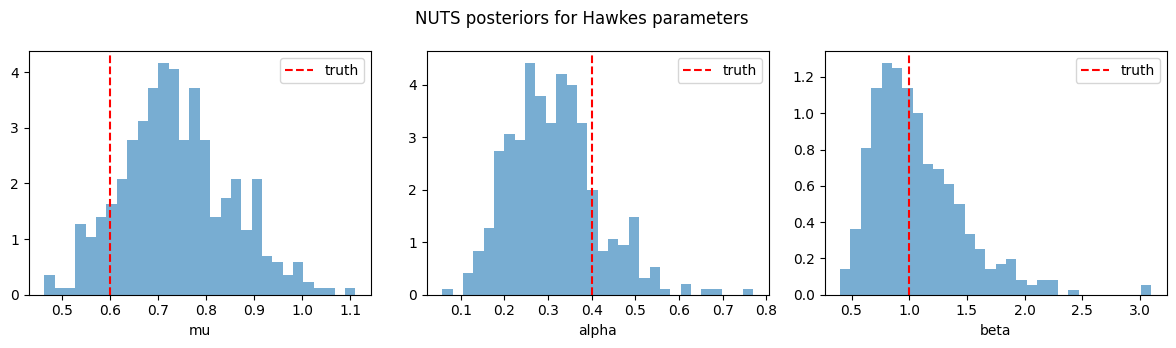

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (name, truth) in zip(
    axes, [("mu", true_mu), ("alpha", true_alpha), ("beta", true_beta)]
):
    ax.hist(np.asarray(samples[name]), bins=30, density=True, alpha=0.6)
    ax.axvline(truth, color="red", linestyle="--", label="truth")
    ax.set_xlabel(name)
    ax.legend()
plt.suptitle("NUTS posteriors for Hawkes parameters")
plt.tight_layout()
plt.show()

All three parameters are recovered; the branching ratio $\alpha / \beta$ is the hardest to pin down because the compensator factors alpha and beta through the same $\Lambda(T)$ term — more events and longer $T$ tighten it.